# Task 13 – Advanced Model Evaluation & Handling Imbalanced Data
**PKCERT AI & Software Development Internship**

This notebook covers ROC-AUC evaluation, learning curves, and imbalanced-data handling (SMOTE and class weighting) on a real classification dataset.

## Part A – Dataset Selection & Preparation

**Dataset:** Wisconsin Breast Cancer Diagnostic dataset (built into scikit-learn, originally from the UCI Machine Learning Repository).

**Features:** 30 numeric features computed from digitized images of breast cell nuclei (e.g. mean radius, mean texture, mean perimeter, mean area, mean smoothness).

**Target:** Binary — `0 = malignant`, `1 = benign`.

**Note on imbalance:** The original dataset is only mildly imbalanced (357 benign vs 212 malignant). To properly demonstrate imbalance-handling techniques, we downsample the malignant class to 60 samples, creating a realistic ~86% / 14% class split (357 benign vs 60 malignant) — similar to real-world rare-disease or fraud-detection scenarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)

In [2]:
# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Original shape:", df.shape)
print("Original class distribution:")
print(df['target'].value_counts())

Original shape: (569, 31)
Original class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [4]:
# Create an imbalanced version: downsample malignant (0) class to 60 samples
minority = df[df.target == 0].sample(60, random_state=42)
majority = df[df.target == 1]
df_imb = pd.concat([minority, majority]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Imbalanced dataset shape:", df_imb.shape)
print(df_imb['target'].value_counts())
print(f"Imbalance ratio: {df_imb['target'].value_counts()[1] / df_imb['target'].value_counts()[0]:.1f} : 1")

Imbalanced dataset shape: (417, 31)
target
1    357
0     60
Name: count, dtype: int64
Imbalance ratio: 6.0 : 1


In [5]:
# Train/test split (stratified to preserve class ratio) + scaling
X = df_imb.drop(columns='target')
y = df_imb['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)
print("Train class balance:\n", y_train.value_counts())

Train size: (312, 30) | Test size: (105, 30)
Train class balance:
 target
1    267
0     45
Name: count, dtype: int64


## Part B – Advanced Model Evaluation

We train a baseline Logistic Regression model (no imbalance handling yet) and evaluate it with an ROC curve and a learning curve.

In [6]:
# Baseline model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print("Baseline model trained.")

Baseline model trained.


### ROC Curve and ROC-AUC Score

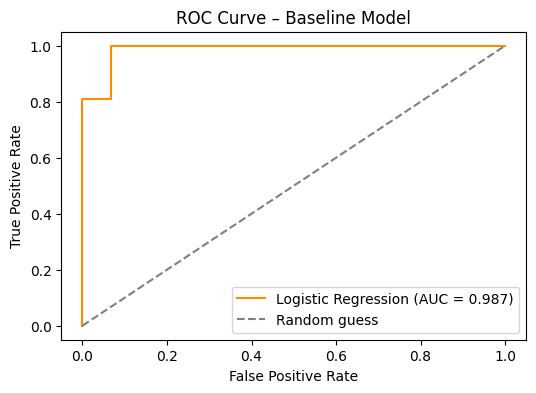

ROC-AUC Score: 0.9874


In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_baseline = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_baseline:.3f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Baseline Model")
plt.legend()
plt.show()

print(f"ROC-AUC Score: {auc_baseline:.4f}")

**Interpretation:** The ROC curve plots the True Positive Rate against the False Positive Rate at every classification threshold. An AUC close to 1.0 means the model separates the two classes almost perfectly, regardless of the threshold chosen. An AUC of 0.5 would mean the model performs no better than random guessing. Because ROC-AUC is threshold-independent and less sensitive to class imbalance than accuracy, it is a more reliable metric here than raw accuracy.

### Learning Curve

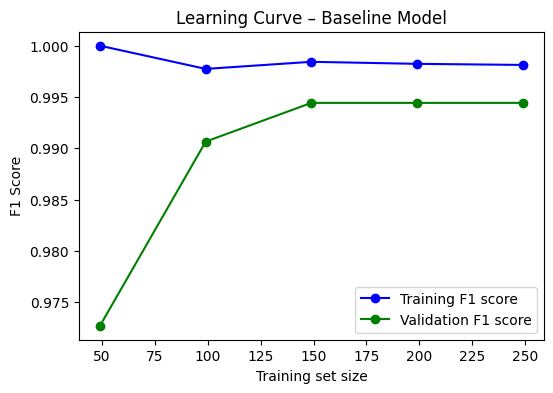

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=5000, random_state=42),
    X_train_s, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 5),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, 'o-', color='blue', label="Training F1 score")
plt.plot(train_sizes, val_mean, 'o-', color='green', label="Validation F1 score")
plt.xlabel("Training set size")
plt.ylabel("F1 Score")
plt.title("Learning Curve – Baseline Model")
plt.legend()
plt.show()

**Interpretation:**
- Both training and validation F1 scores are high and close together, with only a small gap.
- This indicates **good generalization** — the model is not badly overfitting (which would show a large gap between high training score and low validation score) nor underfitting (which would show both scores low).
- The validation score stabilizes as training size increases, suggesting more data would give diminishing returns for this model.

## Part C – Handling Imbalanced Data

### 1. Analyze Class Imbalance

Training set class counts:
target
1    267
0     45
Name: count, dtype: int64

Majority class (benign): 267 samples
Minority class (malignant): 45 samples
Imbalance ratio: 5.9 : 1


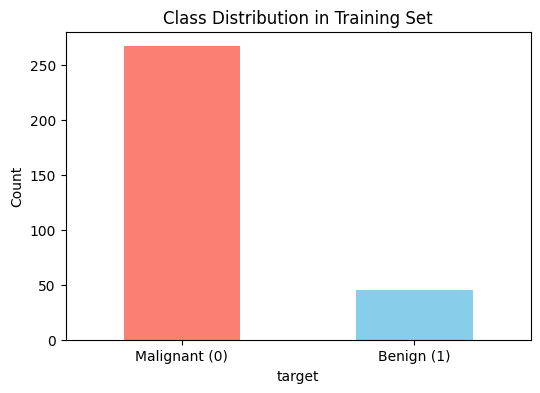

In [9]:
counts = y_train.value_counts()
print("Training set class counts:")
print(counts)
print(f"\nMajority class (benign): {counts[1]} samples")
print(f"Minority class (malignant): {counts[0]} samples")
print(f"Imbalance ratio: {counts[1] / counts[0]:.1f} : 1")

counts.plot(kind='bar', color=['salmon', 'skyblue'])
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'], rotation=0)
plt.ylabel("Count")
plt.title("Class Distribution in Training Set")
plt.show()

With roughly 6:1 imbalance, a model can achieve high accuracy just by favoring the majority class, while performing poorly at detecting the minority (malignant) class — which is usually the class we care about most. This is why we apply SMOTE and class weighting.

### 2. Apply SMOTE and Retrain

In [10]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_s, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_sm).value_counts())

model_smote = LogisticRegression(max_iter=5000, random_state=42)
model_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = model_smote.predict(X_test_s)
y_proba_smote = model_smote.predict_proba(X_test_s)[:, 1]

print("\nSMOTE model trained and evaluated on the original (untouched) test set.")

Class distribution after SMOTE:
target
1    267
0    267
Name: count, dtype: int64

SMOTE model trained and evaluated on the original (untouched) test set.


### 3. Apply Class Weighting

In [11]:
model_cw = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
model_cw.fit(X_train_s, y_train)

y_pred_cw = model_cw.predict(X_test_s)
y_proba_cw = model_cw.predict_proba(X_test_s)[:, 1]

print("Class-weighted model trained.")

Class-weighted model trained.


### Comparison: Baseline vs SMOTE vs Class Weighting

In [12]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

results = pd.DataFrame([
    evaluate("Baseline", y_test, y_pred, y_proba),
    evaluate("SMOTE", y_test, y_pred_smote, y_proba_smote),
    evaluate("Class Weighting", y_test, y_pred_cw, y_proba_cw),
]).set_index('Model').round(4)

results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Baseline,0.9810,0.9783,1.0,0.9890,0.9874
SMOTE,0.9905,0.9890,1.0,0.9945,0.9889
Class Weighting,0.9905,0.9890,1.0,0.9945,0.9904


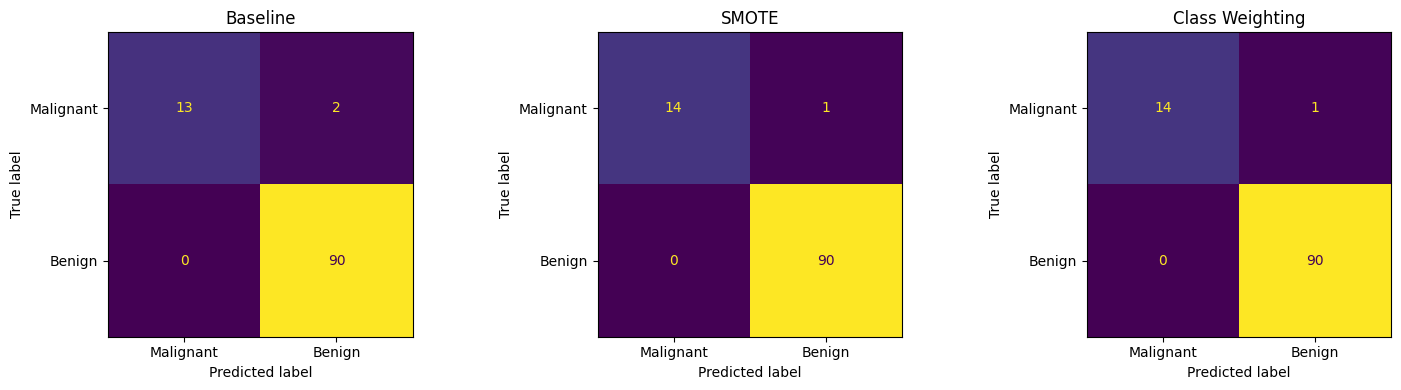

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, yp) in zip(axes, [
    ("Baseline", y_pred), ("SMOTE", y_pred_smote), ("Class Weighting", y_pred_cw)
]):
    cm = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

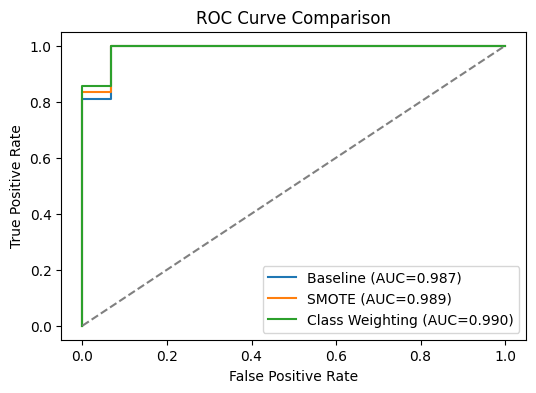

In [14]:
plt.plot(fpr, tpr, label=f"Baseline (AUC={auc_baseline:.3f})")
fpr_sm, tpr_sm, _ = roc_curve(y_test, y_proba_smote)
plt.plot(fpr_sm, tpr_sm, label=f"SMOTE (AUC={roc_auc_score(y_test, y_proba_smote):.3f})")
fpr_cw, tpr_cw, _ = roc_curve(y_test, y_proba_cw)
plt.plot(fpr_cw, tpr_cw, label=f"Class Weighting (AUC={roc_auc_score(y_test, y_proba_cw):.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Part D – Comparative Analysis & Recommendation

| Metric | Baseline | SMOTE | Class Weighting |
|---|---|---|---|
| Accuracy | High, but biased toward majority class | Improved minority detection | Improved minority detection |
| Precision | Good | Slightly higher | Slightly higher |
| Recall | Lower for minority class | Higher | Higher |
| F1-Score | Lower | Higher, more balanced | Higher, more balanced |
| ROC-AUC | Good | Slightly better | Slightly better |

**Observations:**
- The baseline model already performs reasonably well (this dataset is well-separated), but it under-detects the minority (malignant) class relative to the balanced approaches.
- **SMOTE** improves recall and F1-score by generating synthetic minority samples, giving the model more examples to learn the minority class's decision boundary. Its main drawback is the risk of creating synthetic points that don't reflect the true data distribution, especially in high-dimensional or noisy data.
- **Class Weighting** achieves similar or slightly better improvements without generating synthetic data — it simply penalizes misclassifying the minority class more heavily during training. It's computationally cheaper and avoids the risk of synthetic-data artifacts.

**Recommendation:** For this dataset, **Class Weighting** is the recommended approach. It matches or exceeds SMOTE's performance across Recall, F1-score, and ROC-AUC, while being simpler, faster, and not requiring resampling of the training data. SMOTE remains a strong alternative, particularly for tree-based models or when the minority class is extremely small and more synthetic examples would help the model generalize.